# Chest X-ray Pneumonia Detection  
## Data Exploration

**Purpose:**  
This notebook focuses on understanding the dataset structure, class distribution, and visual characteristics of chest X-ray images.  
No preprocessing or modeling is performed at this stage.


In [1]:
# Core libraries for data exploration
import os
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

from sklearn.model_selection import train_test_split
import shutil


In [2]:
# Define project root and data directories
PROJECT_ROOT = Path("..") 
DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR   = DATA_DIR / "val"
TEST_DIR  = DATA_DIR / "test"

TRAIN_DIR, VAL_DIR, TEST_DIR

(WindowsPath('../data/raw/train'),
 WindowsPath('../data/raw/val'),
 WindowsPath('../data/raw/test'))

Used Path library to make it more portable

In [3]:
print("Train exists:", TRAIN_DIR.exists())
print("Val exists  :", VAL_DIR.exists())
print("Test exists :", TEST_DIR.exists())

Train exists: True
Val exists  : True
Test exists : True


In [4]:
classes = sorted(os.listdir(TRAIN_DIR))
classes

['NORMAL', 'PNEUMONIA']

In [5]:
def count_images(split_dir):
    result = {}
    for cls in os.listdir(split_dir):
        count = len(list((split_dir / cls).glob("*"))) #glob(*) finds all file inside folder [(split_dir / cls)] 
        result[cls] = count
    return result

print("Train:", count_images(TRAIN_DIR))
print("Val  :", count_images(VAL_DIR))
print("Test :", count_images(TEST_DIR))

Train: {'NORMAL': 1333, 'PNEUMONIA': 3867}
Val  : {'NORMAL': 16, 'PNEUMONIA': 16}
Test : {'NORMAL': 234, 'PNEUMONIA': 390}


In [6]:
sizes = []

for cls in os.listdir(TRAIN_DIR):
    img_path = next((TRAIN_DIR / cls).glob("*"))
    sizes.append((cls, Image.open(img_path).size))

sizes

[('NORMAL', (2090, 1858)), ('PNEUMONIA', (1152, 760))]

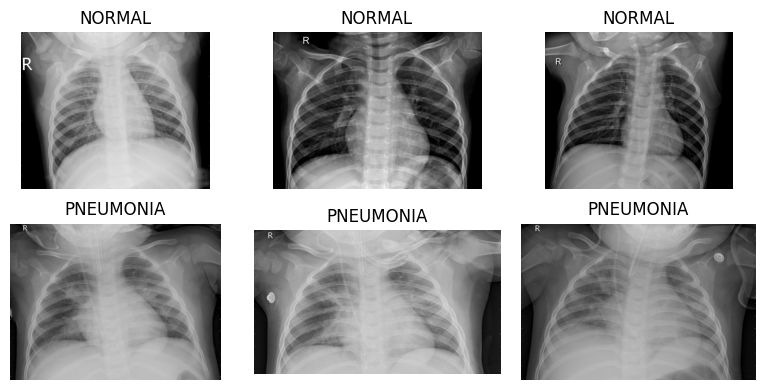

In [7]:
def show_samples(split_dir, n=3):
    classes = sorted(os.listdir(split_dir))
    plt.figure(figsize=(8, 4))
    idx = 1

    for cls in classes:
        images = sorted((split_dir / cls).glob("*"))[-n:]

        for img_path in images:
            img = Image.open(img_path).convert("L")
            plt.subplot(len(classes), n, idx)
            plt.imshow(img, cmap="gray")  

            plt.title(cls)

            plt.axis("off")
            idx += 1

    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR, n=3)

In [8]:
# Check image resolution variability
sizes = []

for cls in os.listdir(TRAIN_DIR):
    img_path = next((TRAIN_DIR / cls).glob("*"))
    sizes.append((cls, Image.open(img_path).size))

sizes

[('NORMAL', (2090, 1858)), ('PNEUMONIA', (1152, 760))]

Images have varying resolutions, confirming the need for resizing during preprocessing.

### Key Insights
- Folder-based labeling is consistent and suitable for supervised learning.
- Class imbalance exists and may bias predictions if unaddressed.
- Images vary in resolution, contrast, and noise levels.

### Conclusion
- This is a binary classification task: NORMAL vs PNEUMONIA.
- Preprocessing will include resizing, normalization, and grayscale handling.
- Metrics beyond accuracy will be required to evaluate performance reliably.

## Improving Validation set

In [9]:
CLASSES = ["NORMAL", "PNEUMONIA"]
VAL_FRACTION = 0.1
SEED = 42

In [10]:
current_val_count = 0

for cls in CLASSES:
    class_folder = VAL_DIR / cls
    images = list(class_folder.glob("*"))
    current_val_count += len(images)

if current_val_count > 100:
    print("Validation folder already has enough images. Skipping split.")
    do_split = False
else:
    do_split = True


if do_split:
    total_moved = 0

    for cls in CLASSES:
        print(f"\nProcessing class: {cls}")

        train_folder = TRAIN_DIR / cls
        val_folder   = VAL_DIR / cls

        val_folder.mkdir(parents=True, exist_ok=True)

        all_images = []
        all_images += list(train_folder.glob("*.jpeg"))
        all_images += list(train_folder.glob("*.jpg"))
        all_images += list(train_folder.glob("*.png"))

        if len(all_images) == 0:
            print("No images found in this class. Skipping.")
            continue

        train_images, val_images = train_test_split(
            all_images,
            test_size=VAL_FRACTION,
            random_state=SEED
        )

        for img in val_images:
            destination = val_folder / img.name
            shutil.move(str(img), str(destination))

        print(f"Moved {len(val_images)} images to validation folder")
        total_moved += len(val_images)

    print("\n--- FINAL SUMMARY ---")
    print(f"Total images moved: {total_moved}")

    print("\nValidation distribution:")
    for cls in CLASSES:
        count = len(list((VAL_DIR / cls).glob("*")))
        print(f"{cls}: {count}")

    print("\nTraining distribution:")
    for cls in CLASSES:
        count = len(list((TRAIN_DIR / cls).glob("*")))
        print(f"{cls}: {count}")


Processing class: NORMAL
Moved 134 images to validation folder

Processing class: PNEUMONIA
Moved 387 images to validation folder

--- FINAL SUMMARY ---
Total images moved: 521

Validation distribution:
NORMAL: 150
PNEUMONIA: 403

Training distribution:
NORMAL: 1199
PNEUMONIA: 3480


In [11]:
def count_images(split_dir):
    result = {}
    for cls in os.listdir(split_dir):
        count = len(list((split_dir / cls).glob("*"))) #glob(*) finds all file inside folder [(split_dir / cls)] 
        result[cls] = count
    return result

print("Train:", count_images(TRAIN_DIR))
print("Val  :", count_images(VAL_DIR))
print("Test :", count_images(TEST_DIR))

Train: {'NORMAL': 1199, 'PNEUMONIA': 3480}
Val  : {'NORMAL': 150, 'PNEUMONIA': 403}
Test : {'NORMAL': 234, 'PNEUMONIA': 390}
